# Discharge timeseries
***

***Author:** Chus Casado Rodríguez*<br>
***Date:** 27-03-2025*<br>

**Introduction**<br>
This notebook analyses the daily time series of river discharge to the oceans, and it produces time series of annual and monthly anomalies.

**Output**<br>
* *discharge_annual_anomaly_by_ocean.csv*: yearly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the period 1991-2020, disaggregated by ocean.
* *discharge_montly_anomaly_by_ocean.nc*: monthly time series of discharge anomaly (km3/year) from 1979 to 2024 compared with the monthly averages in the period 1991-2020, disaggregated by ocean.
* *discharge_seasonality_by_ocean.nc*:  monthly climatology of dicharge (mean and standard deviation) for the period 1991-2020, and the monthly values in 2024, disaggregated by ocean.

In [1]:
import os
os.environ['USE_PYGEOS'] = '0'
import numpy as np
import pandas as pd
import geopandas as gpd
# from shapely.geometry import Point
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from pathlib import Path
from tqdm.auto import tqdm
from datetime import datetime
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from scipy.stats import linregress

## Configuration

In [2]:
VAR = 'discharge'

# inputs
PATH_IN = Path('../data/GloFAS') / VAR
POINTS_FILE = PATH_IN / 'outlets_5000km2_ocean.shp'
TS_FILE = PATH_IN / f'{VAR}_outlets.nc'

# outputs
PATH_OUT = Path('../results') / VAR
PATH_PLOT = PATH_OUT / 'plots'
PATH_PLOT.mkdir(parents=True, exist_ok=True)

# climatology
START = datetime(1991, 1, 1)
END = datetime(2020, 12, 31)

map_variables = {
    'runoff': 'rowe',
    'discharge': 'dis24'
}

var_shortname = map_variables[VAR]

## Data

### River outlets

In [3]:
# load modified river outlets
outlets = gpd.read_file(POINTS_FILE).set_index('ID', drop=True)

### Discharge time series

In [4]:
# load extracted discharge time series at the outlets
dis = xr.open_dataset(TS_FILE)[var_shortname]

# rename or drop variables
dis = dis.drop_vars('surface', errors='ignore')
dis = dis.rename({'valid_time': 'time'})

# convert time convention to beginning-of-timestep
dis['time'] = dis['time'] - pd.Timedelta(days=1)
dis = dis.sel(time=slice(datetime(1980, 1, 1), datetime(2025, 1, 1)))

## Processing

### Interannual variability of freshwater discharge
Annual time series and monthly anomalies of freshwater discharge ($\frac{km^3}{yr}$) into the 4 oceans.

In [5]:
dis_year = {}

for ocean in tqdm(outlets.ocean.unique()):

    # rivers draining to that ocean basin
    IDs = outlets[outlets.ocean == ocean].index.tolist()

    # compute time series of total annual discharge into that ocean
    serie = dis.sel(ID=IDs).sum('ID').resample(time='1Y').mean(skipna=True).to_pandas()

    # # convert from m3/s to km3/year
    # serie *= 3600 * 24 * 365 * 1e-9
    
    # convert from m3/s to km3/day
    serie *= 3600 * 24 * 1e-9

    dis_year[ocean] = serie

# convert to DataFrame
dis_year = pd.DataFrame.from_dict(dis_year)
# set index to the first day of the year
dis_year.index = [idx.year for idx in dis_year.index]

# compute anomaly
annual_anomaly = dis_year - dis_year.loc[START.year:END.year].mean(axis=0)
annual_anomaly.index.name = 'year'

# change index to July 1st
annual_anomaly.index = [datetime(year, 7, 1) for year in annual_anomaly.index]

  0%|          | 0/4 [00:00<?, ?it/s]

### Monthly time series of discharge

In [6]:
dis_month = {}
for ocean in tqdm(outlets.ocean.unique()):

    # rivers draining to that ocean basin
    IDs = outlets[outlets.ocean == ocean].index.tolist()

    # compute time series of total annual discharge into that ocean
    serie = dis.sel(ID=IDs).sum('ID').resample(time='1M').mean(skipna=True).to_pandas()
    
    # # convert from m3/s to km3/year
    # serie *= 3600 * 24 * 365 * 1e-9
    
    # convert from m3/s to km3/day
    serie *= 3600 * 24 * 1e-9
    
    dis_month[ocean] = serie

# convert to DataFrame
dis_month = pd.DataFrame.from_dict(dis_month)

# set index to the first day of the month
dis_month.index = [datetime(idx.year, idx.month, 1) for idx in dis_month.index]
dis_month['year'] = dis_month.index.year
dis_month['month'] = dis_month.index.month

# convert to DataArray
ls = []
for ocean in tqdm(outlets.ocean.unique()):
    # pivot the ocean time series
    df = dis_month.pivot(index='month', columns='year', values=ocean)
    
    # convert to xarray.DataArray
    da = xr.DataArray(
        df.values, 
        dims=("month", "year"), 
        coords={
            "month": df.index,
            "year": df.columns,
        },
        name='monthly_discharge'
    )
    
    # add new coordinate: 'ocean'
    da = da.expand_dims(ocean=[ocean])
    
    ls.append(da)
    
# concatenate oceans
dis_month = xr.concat(ls, dim='ocean')

  0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

#### Climatology vs last year

In [7]:
# climatology of monthly discharge
seasonality = xr.Dataset({
    '25': dis_month.sel(year=slice(START.year, END.year)).quantile([.25], dim='year').squeeze('quantile').drop_vars('quantile'),
    'mean': dis_month.sel(year=slice(START.year, END.year)).mean('year'),
    'std': dis_month.sel(year=slice(START.year, END.year)).std('year'),
    '75': dis_month.sel(year=slice(START.year, END.year)).quantile([.75], dim='year').squeeze('quantile').drop_vars('quantile'),
})

# monthly discharge 2024
seasonality['2024'] = dis_month.sel(year=2024).drop_vars('year')

#### Monthly anomalies
For every month in the time series, compute the difference with the climatology of that month in the reference period.

In [8]:
# compute
monthly_anomalies = dis_month - seasonality['mean']

## Plot

In [16]:
plt.rcParams.update({
    "font.size": 14,       # Default font size for text
    "axes.titlesize": 15,  # Title font size
    "axes.labelsize": 14,  # X and Y label font size
    "xtick.labelsize": 13, # X tick font size
    "ytick.labelsize": 13, # Y tick font size
    "legend.fontsize": 12  # Legend font size
})

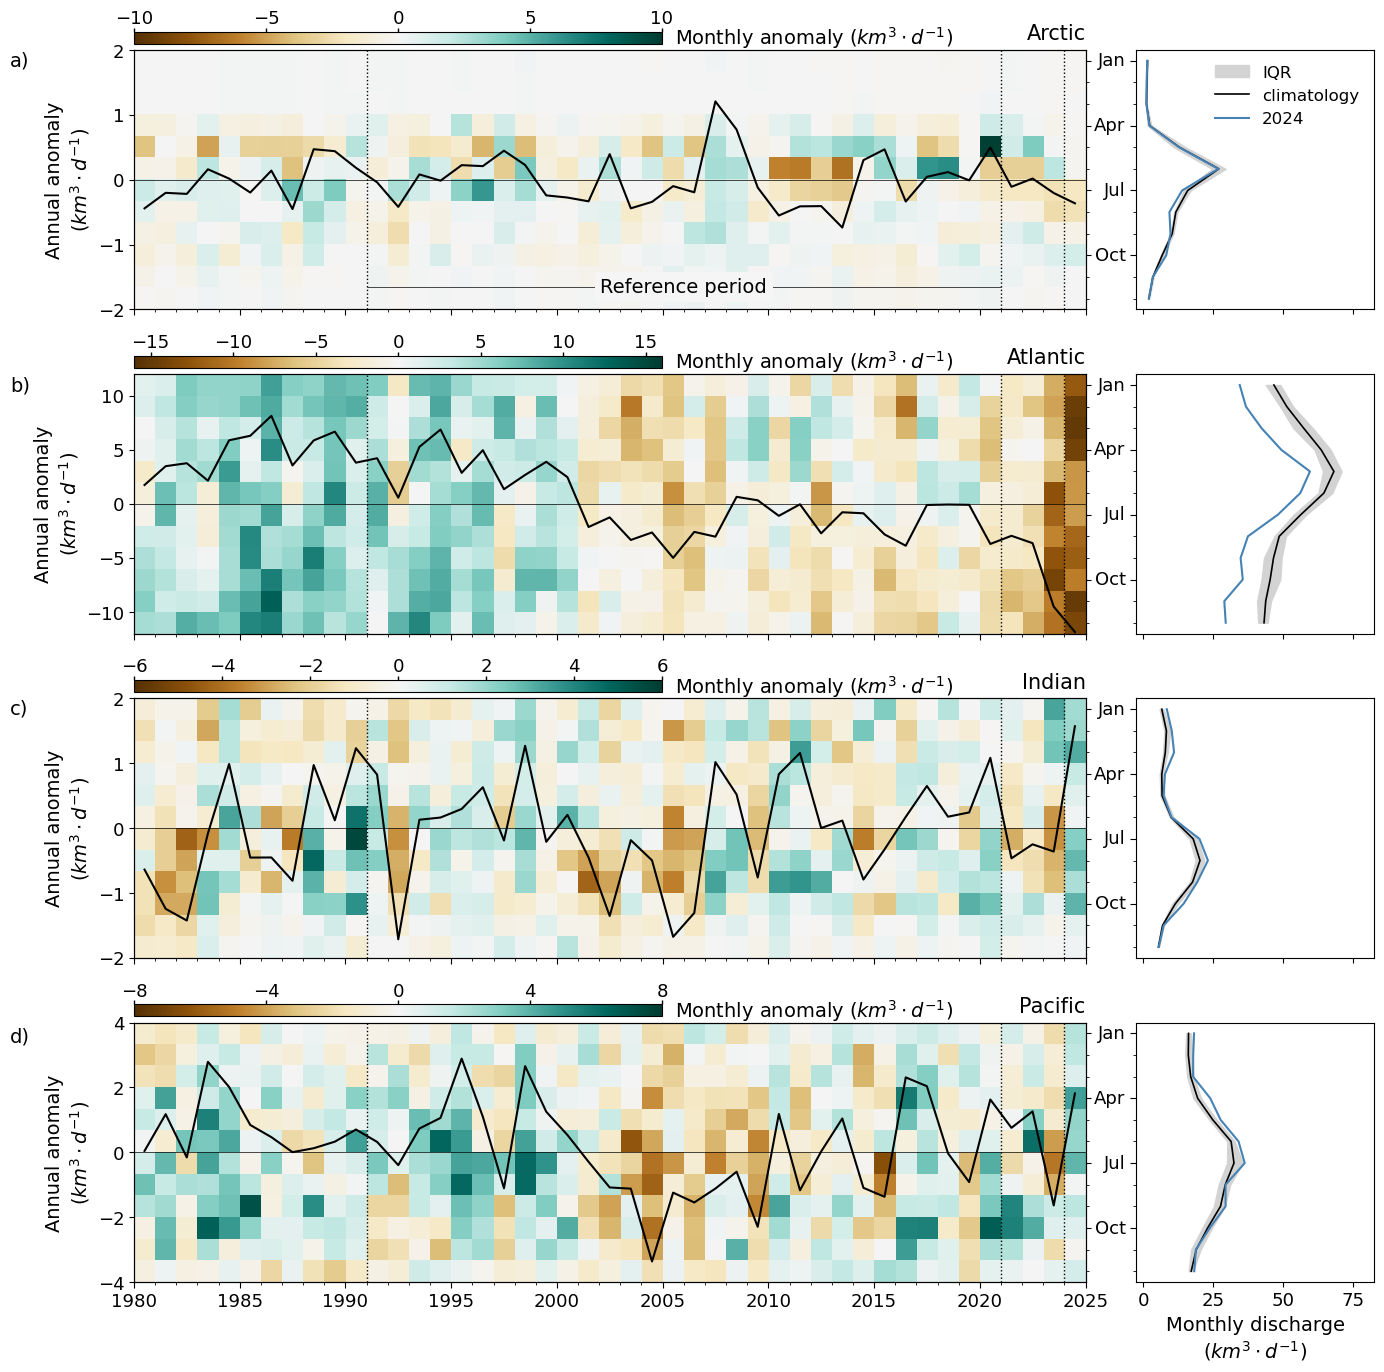

In [45]:
xlim = (datetime(1980, 1, 1), datetime(2025, 1, 1))
cmap = 'BrBG'

fig = plt.figure(figsize=(16, 16))
gs = gridspec.GridSpec(nrows=4, ncols=2, width_ratios=[4, 1], hspace=.25, wspace=0.085)

# create subplots
axes_main = [fig.add_subplot(gs[i, 0]) for i in range(4)]
axes_side = [fig.add_subplot(gs[i, 1]) for i in range(4)]
for ax_main, ax_side, ocean in zip(axes_main, axes_side, sorted(outlets.ocean.unique())):
    
    # ===== MAIN TIME SERIES PLOT =====
    
    # ANNUAL ANOMALY
    
    anomaly = annual_anomaly[ocean]
    
    # lineplot of annual anomalies
    ax_main.plot(anomaly.loc[xlim[0]:xlim[-1]], c='k', lw=1.5, zorder=3)
    ax_main.axhline(0, c='k', lw=.5, zorder=2)
    
    vmax = max(abs(anomaly.max()), abs(anomaly.min()))
    # exp = len(str(int(vmax))) - 1
    # vmax = np.ceil(vmax / 10**exp) * 10**exp
    vmax = np.ceil(vmax / 2) * 2
    
    # MONTHLY ANOMALIES
    
    # heatmap
    da = monthly_anomalies.sel(ocean=ocean, year=slice(xlim[0].year, xlim[-1].year))
    cb_max = np.abs(da).max(['month', 'year']).item()
    # exp = len(str(int(cb_max))) - 1
    # cb_max = np.ceil(cb_max / 10**exp) * 10**exp
    cb_max = np.ceil(cb_max / 2) * 2
    im = ax_main.imshow(
        da.data, #[::-1,:],
        cmap=cmap,
        vmin=-cb_max,
        vmax=cb_max,
        aspect='auto',
        extent=(0, 1, 0, 1),
        transform=ax_main.transAxes,
        zorder=1
    )
    
    # reference period
    for date in [START, END, datetime(2024, 1, 1)]:
        ax_main.axvline(date, c='k', ls=':', lw=1, zorder=1)
    if ax_main == axes_main[0]:
        y_pos = -vmax * .825
        ax_main.hlines(y_pos, START, END, color='k', ls='-', lw=.5, zorder=1)
        ax_main.text(START + (END - START) / 2, y_pos, 'Reference period', ha='center', va='center', bbox=dict(facecolor='whitesmoke', edgecolor='none'))
        
    # colorbar
    cbar_ax = fig.add_axes([ax_main.get_position().x0, ax_main.get_position().y1 + 0.004, 0.33, 0.0075])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
    cbar_ax.tick_params(axis="x", direction="out", top=True, bottom=False, labeltop=True, labelbottom=False, length=3, width=1, pad=0)
    cbar_ax.text(1.025, .5, 'Monthly anomaly ($km^3 \\cdot d^{-1}$)', ha='left', va='center', transform=cbar_ax.transAxes)
    ticks = [tick for tick in cbar.get_ticks() if (tick >= -cb_max) & (tick <= cb_max)]
    if len(ticks) > 7:
        ticks = ticks[::2]
        cbar.set_ticks(ticks)
        
    # CONFIGURATION
    
    ax_main.text(1.0, 1.04, ocean, fontsize=15, ha='right', transform=ax_main.transAxes)
    ax_main.set(
        xlim=xlim,
        ylim=(-vmax, vmax),
        ylabel='Annual anomaly\n$(km^3 \\cdot d^{-1})$',
    )
    yticks = [tick for tick in ax_main.get_yticks() if (tick >= -vmax) & (tick <= vmax)]
    if len(yticks) > 7:
        yticks = yticks[::2]
    ax_main.set_yticks(yticks)
    ax_main.tick_params(axis="x", which='major', direction="out", bottom=True, length=4)
    ax_main.tick_params(axis='x', which='minor', direction="out", bottom=True, length=2)
    ax_main.xaxis.set_major_locator(mdates.YearLocator(5))
    ax_main.xaxis.set_minor_locator(mdates.YearLocator(1))
    if ax_main != axes_main[-1]:
        ax_main.set_xticklabels([])
        
    ax_main2 = ax_main.twinx()
    ax_main2.set(
        ylim=(.5, 12.5),
        yticks=range(3, 13, 3),
        yticklabels=[]
    )
    ax_main2.yaxis.set_minor_locator(ticker.MultipleLocator(1))
        
    # ===== SEASONAL PLOT =====
    
    # extract monthly values
    mean = seasonality['mean'].sel(ocean=ocean).isel(month=slice(None, None, -1)).to_pandas()
    p25 = seasonality['25'].sel(ocean=ocean).isel(month=slice(None, None, -1)).to_pandas()
    p75 = seasonality['75'].sel(ocean=ocean).isel(month=slice(None, None, -1)).to_pandas()
    target = seasonality['2024'].sel(ocean=ocean).isel(month=slice(None, None, -1)).to_pandas()
    
    ax_side.fill_betweenx(
        seasonality.month,
        p25,
        p75,
        color='lightgray',
        zorder=0,
        label='IQR',
    )
    ax_side.plot(mean.values, range(1, 13, 1), c='k', lw=1.2, zorder=1, label='climatology')
    ax_side.plot(target.values, range(1, 13, 1), c='steelblue', lw=1.5, zorder=2, label='2024')
    
    # config
    ax_side.set(
        xlim=(-2.5, 82.5),
        ylim=(.5, 12.5),
        yticks=range(1, 13, 3),
    )
    ax_side.tick_params(axis='y', which='major', direction="out", left=True, length=4)
    ax_side.tick_params(axis='y', which='minor', direction="out", left=True, length=2)
    ax_side.yaxis.set_major_locator(ticker.FixedLocator(range(3, 13, 3)[::-1]))
    ax_side.yaxis.set_minor_locator(ticker.MultipleLocator(1))
    ax_side.set_yticklabels(['Jan', 'Apr', 'Jul', 'Oct'], rotation=0, va='center', ha='right')
    if ax_side == axes_side[-1]:
        ax_side.set_xlabel('Monthly discharge\n($km^3 \\cdot d^{-1}$)')
    else:
        ax_side.set_xticklabels([])
    if ax_side == axes_side[0]:
        ax_side.legend(loc=1, frameon=False)
        
# panel names
fig.text(0.0475, .87, 'a)')
fig.text(0.0475, .667, 'b)')
fig.text(0.0475, .465, 'c)')
fig.text(0.0475, .26, 'd)');

# plt.savefig(PATH_PLOT / f'interannual_variability_{VAR}.jpg', dpi=300, bbox_inches='tight');
plt.savefig(PATH_PLOT / f'interannual_variability_{VAR}.eps', format='eps', dpi=300, bbox_inches='tight');

## Export

In [10]:
# annual anomaly
output_file = PATH_OUT / f'{VAR}_annual_anomaly_by_ocean.csv'
annual_anomaly.to_csv(output_file, float_format='%.0f')
print(f'Annual anomalies of discharge saved in:\t{output_file}')

Annual anomalies of discharge saved in:	..\results\discharge\discharge_annual_anomaly_by_ocean.csv


In [11]:
# seasonality
output_file = PATH_OUT / f'{VAR}_seasonality_by_ocean.nc'
seasonality.to_netcdf(output_file)
print(f'Discharge seasonality saved in:\t{output_file}')

Discharge seasonality saved in:	..\results\discharge\discharge_seasonality_by_ocean.nc


In [12]:
# monthly anomalies
output_file = PATH_OUT / f'{VAR}_monthly_anomaly_by_ocean.nc'
monthly_anomalies.to_netcdf(output_file)
print(f'Discharge monthly anomalies saved in:\t{output_file}')

Discharge monthly anomalies saved in:	..\results\discharge\discharge_monthly_anomaly_by_ocean.nc


***

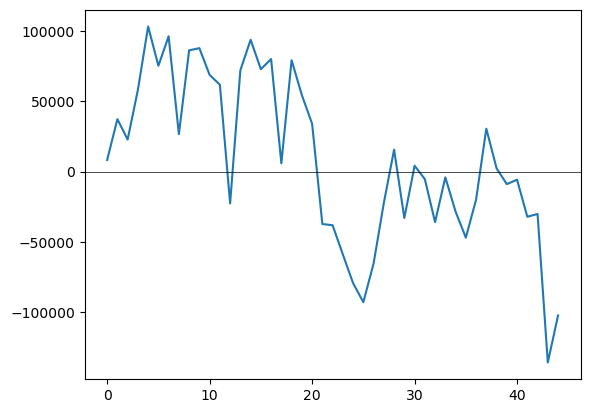

In [97]:
total_dis = dis.sum('ID')

mean_dis = total_dis.sel(time=slice(START, END)).mean('time')

total_dis_anomaly = total_dis - mean_dis

fig, ax = plt.subplots()

ax.plot(total_dis_anomaly.resample({'time': '1Y'}).mean())
ax.axhline(0, c='k', lw=.5)

<AxesSubplot:>

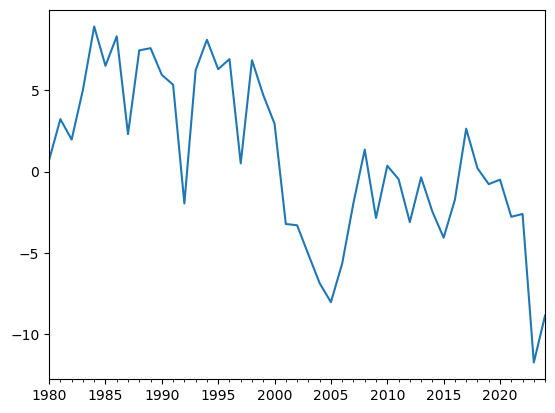

In [86]:
annual_anomaly.sum(axis=1).plot()

## Extra analysis
### Specific discharge

In [14]:
# specific discharge
area_skm = xr.DataArray(outlets['area'])
dis_sp = dis / area_skm * 1e-3 # mm

# annual timeseries of total discharge volume
# dis_yr = (dis * 24 * 3600).resample({'time': 'Y'}).sum() # m3/year
# dis_yr['time'] = dis_yr['time'] - pd.Timedelta(days=183)
dis_sp_yr = (dis_sp * 24 * 3600).groupby(dis_sp.time.dt.year).sum() # m3/year
dis_sp_yr = dis_sp_yr.rename({'year': 'time'})

# # annual time series of specific discharge
# area_skm = xr.DataArray(outlets['area'])
# dis_sp_yr = dis_yr / area_skm * 1e-3 # mm

# add average annual specific discharge to the point layer
dis_sp_mean = dis_sp_yr.mean('time').to_pandas()
dis_sp_mean.name = 'specific_discharge'
if 'specific_discharge' in outlets.columns:
    outlets.drop('specific_discharge', axis=1, inplace=True)
outlets = pd.concat((outlets, pd.DataFrame(dis_sp_mean)), axis=1)

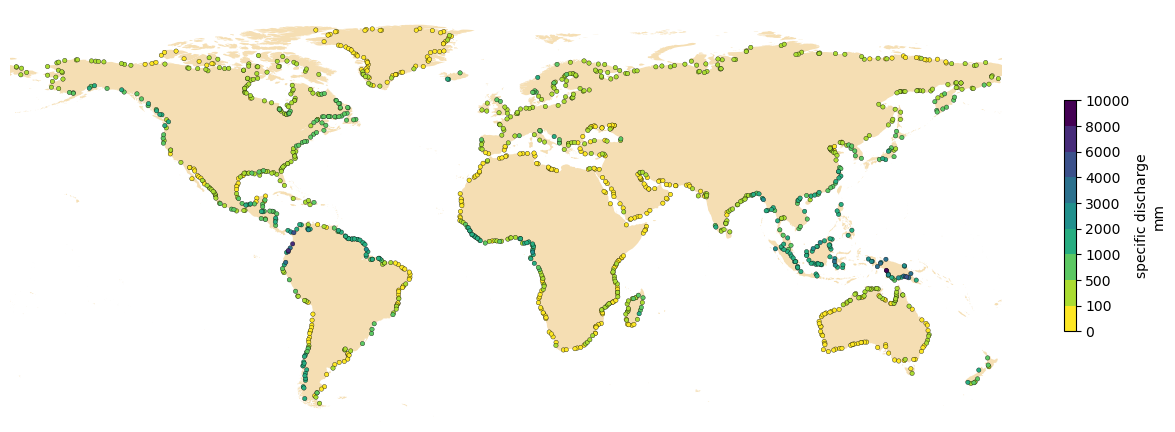

In [35]:
# Define the colormap and normalization
boundaries = [0, 100, 500, 1000, 2000, 3000, 4000, 6000, 8000, 10000]
cmap = plt.cm.viridis_r
ncolors = len(boundaries) - 1
colors = cmap(np.linspace(0, 1, ncolors))
cmap_discrete = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, ncolors, extend='neither')

outlets.sort_values('specific_discharge', inplace=True)

fig, ax = plt.subplots(figsize=(16, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Plot coastlines for continents
ax.add_feature(
    cfeature.NaturalEarthFeature('physical', 'coastline', '50m'),
    edgecolor='none',
    facecolor='wheat',
    linewidth=.8,
    # alpha=.5,
    zorder=0,
)

# scatter plot of annual specific discharge (mm)
sct = ax.scatter(
    outlets.geometry.x,
    outlets.geometry.y,
    c=outlets.specific_discharge,
    s=10,
    cmap=cmap_discrete,
    norm=norm,
    edgecolor='k',
    lw=.25,
)
plt.colorbar(sct, shrink=0.5, label='specific discharge\nmm')
ax.axis('off');

plt.savefig(PATH_PLOT / 'specific_discharge.jpg', dpi=300, bbox_inches='tight');

### Trends in specific discharge

In [17]:
# compute trend in specific discharge
outlets[['intercept', 'slope', 'p_value']] = np.nan
dis_sp_yr = dis_sp_yr.to_pandas()
for ID in tqdm(outlets.index):
    
    # Compute Sen’s slope (simplified as linear regression slope)
    slope, intercept, r_value, p_value, std_err = linregress(dis_sp_yr.index, dis_sp_yr[ID])
    outlets.loc[ID, ['intercept', 'slope', 'p_value']] = intercept, slope, p_value


  0%|          | 0/1310 [00:00<?, ?it/s]

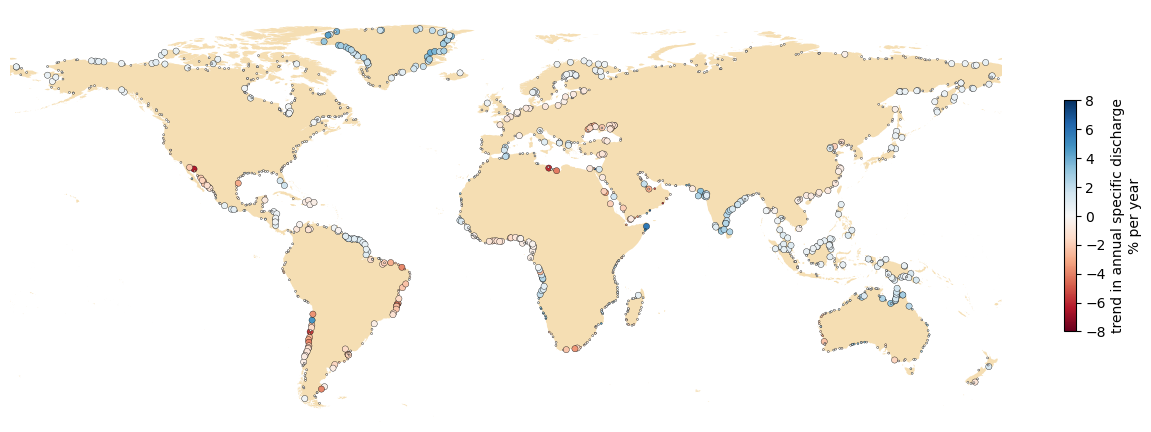

In [23]:
alpha = .05

fig, ax = plt.subplots(figsize=(16, 6), subplot_kw=dict(projection=ccrs.PlateCarree()))

# Plot coastlines for continents
ax.add_feature(
    cfeature.NaturalEarthFeature('physical', 'coastline', '50m'),
    edgecolor='none',
    facecolor='wheat',
    linewidth=.8,
    # alpha=.5,
    zorder=0,
)

sct = ax.scatter(
    outlets.geometry.x,
    outlets.geometry.y,
    c=outlets.slope / outlets.specific_discharge * 100, # outlets.slope
    s=2 * 10**(outlets.p_value < alpha),
    cmap='RdBu',
    edgecolor='k',
    lw=.25,
    vmin=-8, #-40,
    vmax=8, #40,
)
plt.colorbar(sct, shrink=.5, label='trend in annual specific discharge\n% per year') #label='slope\nmm/year')
ax.axis('off');

plt.savefig(PATH_PLOT / 'trends_in_specific_discharge.jpg', dpi=300, bbox_inches='tight');

***